In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2025-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Multivariate Classification — Logistic Regression, LDA, QDA (ISLR Ch. 4)
=========================================================================

Description:
    Demonstrates multivariate binary classification using three methods:
      1. Logistic Regression   (sklearn.LogisticRegression)
      2. Linear Discriminant Analysis — LDA  (sklearn.LinearDiscriminantAnalysis)
      3. Quadratic Discriminant Analysis — QDA (sklearn.QuadraticDiscriminantAnalysis)

    Data is synthetically generated: four predictors (V1–V4), each a mixture
    of two Normal distributions with different means, simulating a multivariate
    classification problem. Response Y is binary (A=0, B=1).

    This notebook extends the univariate vignette (Ch4, notebook #2) to the
    multivariate case: Y ~ V1 + V2 + V3 + V4.

    For each classifier:
      - Fit on train set
      - Predict on test set
      - Confusion matrix
      - Custom PredictionMetrics (OBS, ACC, TPR, TNR, PPV, NPV, FDR, FPR,
        TP, TN, FP, FN, P, N)
      - ROC curve with AUC

    Notes on the original R script:
      - The R ROC for logistic regression used a workaround (p1[,2]) noted
        as potentially buggy — fixed cleanly here using predict_proba.
      - The R LDA and QDA metrics accidentally used lgr.pred instead of
        their own predictions — corrected here.

    R equivalent: multivar_logistic_reg_LDA_QDA_classification.Rmd
    R libraries:  stats (glm), MASS (lda, qda), caret, pROC, ggplot2, GGally
    Python libs:  numpy, pandas, matplotlib, seaborn, sklearn

Dataset:
    Simulated — four predictors (V1–V4), each a mixture of two Normals
    mu_1=0, mu_2=-1, mu_3=-3, mu_4=2 with N=1000 total observations
    Response: Y (binary: 0=A, 1=B)

Revision History:
    2025-01-01  Original R development (Harvard Elements of Statistical Learning, 2021)
                - R script: multivar_logistic_reg_LDA_QDA_classification.Rmd
                - Based on functions from Dr. Sivachenko and Dr. Farutin

    2026-04-03  Converted to Python / Jupyter Notebook
                - glm(Y~., family=binomial) → sklearn.LogisticRegression
                - MASS::lda(Y~.) → sklearn.LinearDiscriminantAnalysis
                - MASS::qda(Y~.) → sklearn.QuadraticDiscriminantAnalysis
                - GGally::ggpairs() → seaborn.pairplot()
                - Fixed R bug: LDA/QDA metrics now use correct predictions
                - Fixed R bug: ROC uses predict_proba directly (no workaround needed)
                - PredictionMetrics class carried from univariate notebook
                - Harvard color palette preserved as hex constants
"""

'\nCreated on 2025-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nMultivariate Classification — Logistic Regression, LDA, QDA (ISLR Ch. 4)\n=========================================================================\n\nDescription:\n    Demonstrates multivariate binary classification using three methods:\n      1. Logistic Regression   (sklearn.LogisticRegression)\n      2. Linear Discriminant Analysis — LDA  (sklearn.LinearDiscriminantAnalysis)\n      3. Quadratic Discriminant Analysis — QDA (sklearn.QuadraticDiscriminantAnalysis)\n\n    Data is synthetically generated: four predictors (V1–V4), each a mixture\n    of two Normal distributions with different means, simulating a multivariate\n    classification problem. Response Y is binary (A=0, B=1).\n\n    

# Multivariate Classification — Logistic Regression, LDA, QDA (ISLR Ch. 4)

## Overview

This notebook extends the **univariate classification vignette** (notebook #2) to the
**multivariate case**: four predictors (V1–V4) predicting a binary outcome Y (A=0, B=1).

Three classifiers from ISLR Chapter 4 are compared:

1. **Logistic Regression** — `Y ~ V1 + V2 + V3 + V4`
2. **Linear Discriminant Analysis (LDA)** — shared covariance, linear boundary
3. **Quadratic Discriminant Analysis (QDA)** — per-class covariance, quadratic boundary

Data is **synthetically generated**: each predictor is a mixture of two Normal
distributions with different means (μ₁=0, μ₂=−1, μ₃=−3, μ₄=2), creating realistic
overlap between classes.

**Notes on improvements over original R script:**
- R's ROC for logistic regression used a `p1[,2]` workaround noted as potentially buggy —
  fixed here using `predict_proba` directly.
- R's LDA and QDA metrics accidentally referenced `lgr.pred` instead of their own
  predictions — corrected here.

**R equivalent:** `multivar_logistic_reg_LDA_QDA_classification.Rmd`

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Classification models — mirrors R: stats::glm, MASS::lda, MASS::qda
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)

# Model evaluation — mirrors R: caret::confusionMatrix, pROC::roc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)

# Display settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# crimson='#A51C30', royalblue='#002366', slate='#8996A0'
# ivy='#52854C', saffron='#D16103', indigo='#293352', shade='#BAC5C6'
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print('Imports complete.')

Imports complete.


## PredictionMetrics Class

Carried from the univariate classification notebook (notebook #2).
Mirrors R functions `prediction.metrics()` and `print.the.metrics()` from
Harvard's Elements of Statistical Learning class (2021),
originally by Dr. Sivachenko and Dr. Farutin, expanded by Oscar Trevizo.

> **Tip for portfolio:** This class is a good candidate to extract into a shared
> `utils.py` module once all classification notebooks are complete.

In [3]:
class PredictionMetrics:
    """
    Binary classification prediction metrics.

    Mirrors R functions prediction.metrics() and print.the.metrics()
    from Harvard Elements of Statistical Learning class (2021).
    Original R code by Dr. Sivachenko and Dr. Farutin; expanded by Oscar Trevizo.

    Parameters
    ----------
    truth : array-like of int (0 or 1)
        Ground truth binary labels.
    predicted : array-like of int (0 or 1)
        Predicted binary labels.

    Attributes
    ----------
    OBS : int    — number of observations
    ACC : float  — accuracy
    TPR : float  — true positive rate (sensitivity)
    TNR : float  — true negative rate (specificity)
    PPV : float  — precision (positive predictive value)
    NPV : float  — negative predictive value
    FDR : float  — false discovery rate
    FPR : float  — false positive rate
    TP, TN, FP, FN : int — confusion matrix counts
    P, N : int   — total positives and negatives in truth
    """

    def __init__(self, truth, predicted):
        truth     = np.array(truth)
        predicted = np.array(predicted)

        if len(truth) != len(predicted):
            raise ValueError('truth and predicted must be the same length!')

        # Remove NaN entries — mirrors R: bKeep = !is.na(truth) & !is.na(predicted)
        mask      = ~(np.isnan(truth.astype(float)) | np.isnan(predicted.astype(float)))
        truth     = truth[mask]
        predicted = predicted[mask]

        # Only 0 and 1 allowed — mirrors R check
        if not np.all(np.isin(truth, [0, 1])) or not np.all(np.isin(predicted, [0, 1])):
            raise ValueError('Only zeroes and ones are allowed!')

        # Confusion matrix counts
        self.TP = int(np.sum((truth == 1) & (predicted == 1)))
        self.TN = int(np.sum((truth == 0) & (predicted == 0)))
        self.FP = int(np.sum((truth == 0) & (predicted == 1)))
        self.FN = int(np.sum((truth == 1) & (predicted == 0)))

        self.P   = self.TP + self.FN
        self.N   = self.FP + self.TN
        self.OBS = len(truth)

        self.ACC = np.sum(truth == predicted) / len(truth)
        self.TPR = self.TP / self.P                      if self.P  > 0 else np.nan
        self.TNR = self.TN / self.N                      if self.N  > 0 else np.nan
        self.PPV = self.TP / (self.TP + self.FP)         if (self.TP + self.FP) > 0 else np.nan
        self.NPV = self.TN / (self.TN + self.FN)         if (self.TN + self.FN) > 0 else np.nan
        self.FDR = self.FP / (self.TP + self.FP)         if (self.TP + self.FP) > 0 else np.nan
        self.FPR = self.FP / self.N                      if self.N  > 0 else np.nan

    def print_metrics(self):
        """Print all metrics — mirrors R: print.the.metrics(metrics)"""
        print(f' OBS = {self.OBS:6d}   ..................number of observations')
        print(f' ACC = {self.ACC:8.4f} ..................Accuracy')
        print(f' TPR = {self.TPR:8.4f} ..................True Positive Rate (Sensitivity)')
        print(f' TNR = {self.TNR:8.4f} ..................True Negative Rate (Specificity)')
        print(f' PPV = {self.PPV:8.4f} ..................Positive Predictive Value (Precision)')
        print(f' NPV = {self.NPV:8.4f} ..................Negative Predictive Value')
        print(f' FDR = {self.FDR:8.4f} ..................False Discovery Rate')
        print(f' FPR = {self.FPR:8.4f} ..................False Positive Rate')
        print(f' TP  = {self.TP:6d}   ..................True Positives')
        print(f' TN  = {self.TN:6d}   ..................True Negatives')
        print(f' FP  = {self.FP:6d}   ..................False Positives')
        print(f' FN  = {self.FN:6d}   ..................False Negatives')
        print(f' P   = {self.P:6d}   ..................Positives (truth)')
        print(f' N   = {self.N:6d}   ..................Negatives (truth)')

    def to_dict(self):
        """Return metrics as a dictionary for tabular comparison."""
        return dict(OBS=self.OBS, ACC=self.ACC, TPR=self.TPR, TNR=self.TNR,
                    PPV=self.PPV, NPV=self.NPV, FDR=self.FDR, FPR=self.FPR,
                    TP=self.TP, TN=self.TN, FP=self.FP, FN=self.FN,
                    P=self.P, N=self.N)


def plot_roc(fpr, tpr, roc_auc, title='ROC Curve', color=ROYALBLUE):
    """
    Plot ROC curve with AUC.
    Mirrors R: pROC::plot.roc() with print.auc=TRUE, auc.polygon=TRUE.

    Parameters
    ----------
    fpr     : array — false positive rates
    tpr     : array — true positive rates
    roc_auc : float — area under the ROC curve
    title   : str
    color   : str   — line color
    """
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'AUC = {roc_auc * 100:.2f}%')
    ax.fill_between(fpr, tpr, alpha=0.15, color='lightblue')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, linestyle='--', linewidth=0.5, color='lightgrey')
    ax.set_xlabel('False Positive Rate (1 - Specificity)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    ax.set_title(title)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


print('PredictionMetrics class and plot_roc() helper defined.')

PredictionMetrics class and plot_roc() helper defined.


---

## Simulate the Data

Mirrors R:
```r
set.seed(11)
N=1000; mu_1=0; mu_2=-1; mu_3=-3; mu_4=2
v1 <- c(rnorm(N/2, mean=mu_1, sd=1), rnorm(N/2, mean=mu_2, sd=1))
v2 <- c(rnorm(N/2, mean=mu_2, sd=1), rnorm(N/2, mean=mu_3, sd=2))
v3 <- c(rnorm(N/2, mean=mu_3, sd=2), rnorm(N/2, mean=mu_4, sd=1))
v4 <- c(rnorm(N/2, mean=mu_4, sd=1), rnorm(N/2, mean=mu_1, sd=1))
y  <- rep(c('A','B'), each=N/2)
df <- data.frame(Y=factor(y), V1=v1, V2=v2, V3=v3, V4=v4)
```

Each predictor is a **mixture of two Normals** — the first N/2 observations drawn
from one mean and the second N/2 from another. This creates structured overlap
between classes A and B across all four predictors.

| Predictor | Class A half | Class B half |
|-----------|-------------|-------------|
| V1 | N(μ₁=0, σ=1) | N(μ₂=−1, σ=1) |
| V2 | N(μ₂=−1, σ=1) | N(μ₃=−3, σ=2) |
| V3 | N(μ₃=−3, σ=2) | N(μ₄=2, σ=1) |
| V4 | N(μ₄=2, σ=1) | N(μ₁=0, σ=1) |

In [4]:
# Simulate data — mirrors R: set.seed(11)
rng = np.random.default_rng(seed=11)

N    = 1000
mu_1 =  0
mu_2 = -1
mu_3 = -3
mu_4 =  2

# Four predictors — each a mixture of two Normal distributions
# mirrors R: c(rnorm(N/2, mean=mu_X, sd=s1), rnorm(N/2, mean=mu_Y, sd=s2))
v1 = np.concatenate([rng.normal(mu_1, 1, N//2), rng.normal(mu_2, 1, N//2)])
v2 = np.concatenate([rng.normal(mu_2, 1, N//2), rng.normal(mu_3, 2, N//2)])
v3 = np.concatenate([rng.normal(mu_3, 2, N//2), rng.normal(mu_4, 1, N//2)])
v4 = np.concatenate([rng.normal(mu_4, 1, N//2), rng.normal(mu_1, 1, N//2)])

# Outcome labels — mirrors R: y <- rep(c('A','B'), each=N/2)
y_label = np.array(['A'] * (N//2) + ['B'] * (N//2))

# Build DataFrame — mirrors R: data.frame(Y=factor(y), V1=v1, ...)
# Y encoded as 0=A, 1=B for sklearn compatibility
df = pd.DataFrame({
    'Y' : y_label,                             # string labels 'A'/'B'
    'Y_num': np.where(y_label == 'A', 0, 1),   # numeric 0/1 for metrics
    'V1': v1,
    'V2': v2,
    'V3': v3,
    'V4': v4
})

print(f'Dataset shape: {df.shape}')
print(f'Class balance: {df["Y"].value_counts().to_dict()}')
print()
df[['V1','V2','V3','V4']].describe().round(4)

Dataset shape: (1000, 6)
Class balance: {'A': 500, 'B': 500}



,V1,V2,V3,V4
count,1000.0000,1000.0000,1000.0000,1000.0000
mean,-0.4836,-1.9990,-0.4487,0.9876
std,1.1260,1.8570,3.0077,1.3581
min,-3.7632,-8.7539,-8.6786,-2.7969
25%,-1.2535,-3.0865,-2.8681,-0.0290
50%,-0.4676,-1.6596,0.3338,1.0032
75%,0.3284,-0.6917,2.1125,1.9625
max,3.6236,3.0672,5.7316,4.5062


## Pair Plot

Mirrors R: `GGally::ggpairs(df, aes(color=Y, alpha=0.5))`

The pairplot reveals the joint distributions of all four predictors colored by class.
Unlike the univariate case, the multivariate structure shows how predictors
interact to separate classes A and B.

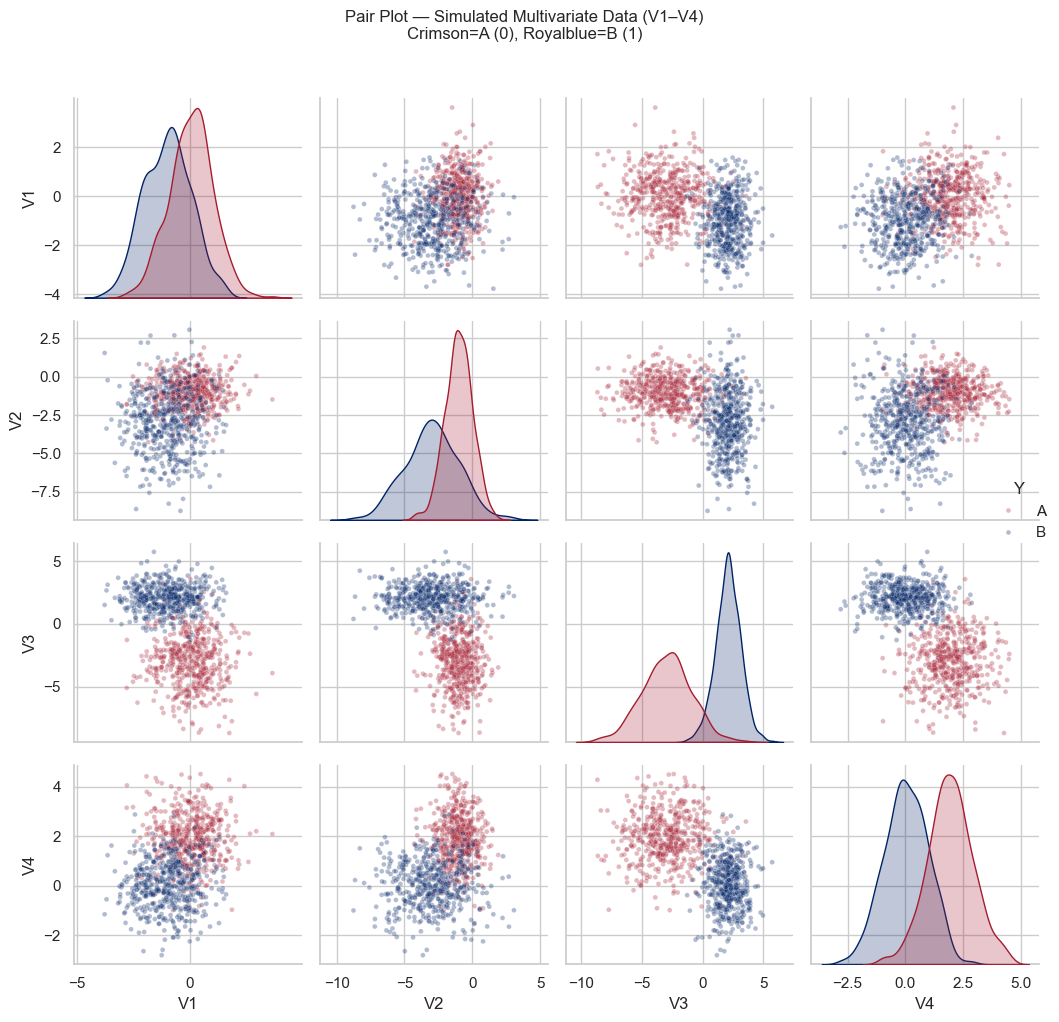

In [5]:
# Pairplot — mirrors R: GGally::ggpairs(df, aes(color=Y, alpha=0.5))
# palette mirrors R: scale_colour_manual(values=c(crimson, royalblue))
palette = {'A': CRIMSON, 'B': ROYALBLUE}

g = sns.pairplot(df[['V1', 'V2', 'V3', 'V4', 'Y']],
                 hue='Y',
                 palette=palette,
                 plot_kws={'alpha': 0.3, 's': 12},
                 diag_kind='kde',
                 corner=False)   # corner=False shows full matrix, mirrors ggpairs default

g.figure.suptitle('Pair Plot — Simulated Multivariate Data (V1–V4)\n'
                  'Crimson=A (0), Royalblue=B (1)',
                  y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Train / Test Split

Mirrors R (Method #2 from the script):
```r
set.seed(12321)
ind <- sample(2, nrow(df), replace=TRUE, prob=c(0.7, 0.3))
df.train <- df[ind==1,]
df.test  <- df[ind==2,]
```

In [6]:
# Train/test split — mirrors R: sample(2, nrow(df), prob=c(0.7, 0.3))
df_train, df_test = train_test_split(df, test_size=0.3, random_state=12321)

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

# Feature matrix and labels
# Y~. in R means all predictors — here V1, V2, V3, V4
FEATURES = ['V1', 'V2', 'V3', 'V4']

X_train   = df_train[FEATURES]
y_train   = df_train['Y']           # string 'A'/'B' — sklearn handles directly
y_train_n = df_train['Y_num']       # numeric 0/1 — for PredictionMetrics

X_test    = df_test[FEATURES]
y_test    = df_test['Y']
y_test_n  = df_test['Y_num']

print(f'Train shape : {df_train.shape}')
print(f'Test shape  : {df_test.shape}')
print(f'Train class balance: {df_train["Y"].value_counts().to_dict()}')
print(f'Test  class balance: {df_test["Y"].value_counts().to_dict()}')

Train shape : (700, 6)
Test shape  : (300, 6)
Train class balance: {'B': 363, 'A': 337}
Test  class balance: {'A': 163, 'B': 137}


---

# 1. Logistic Regression

Mirrors R: `glm(Y ~ ., data=df.train, family=binomial)`

The `.` in R's formula means **all remaining columns** — equivalent to passing
all four predictors V1–V4 as `X_train`.

## Fit the Model

In [7]:
# Fit logistic regression — mirrors R: glm(Y~., family=binomial)
# penalty=None removes regularization, mirroring R's unpenalized GLM
lgr = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
lgr.fit(X_train, y_train)

print('Logistic Regression — Model Summary')
print(f'  Classes     : {lgr.classes_}')
print(f'  Intercept   : {lgr.intercept_[0]:.6f}')
print()
print('  Coefficients:')
for feat, coef in zip(FEATURES, lgr.coef_[0]):
    print(f'    {feat}: {coef:.6f}')

Logistic Regression — Model Summary
  Classes     : ['A' 'B']
  Intercept   : -0.078198

  Coefficients:
    V1: -1.216280
    V2: -0.638196
    V3: 1.923672
    V4: -2.103477


/Users/otrevizo/.venvs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Predict

Mirrors R:
```r
glm.probs <- predict(glm.fit, newdata=df.test, type='response')
glm.pred  <- rep(0, dim(df.test)[1])
glm.pred[glm.probs > 0.5] <- 1
```

**Note on R ROC bug:** The original R script used `predict(..., type='terms')[,2]`
as a workaround for the ROC, commented as potentially buggy. In Python we use
`predict_proba()[:, 1]` directly — clean and correct.

In [8]:
# Predicted probabilities — mirrors R: predict(glm.fit, type='response')
lgr_probs = lgr.predict_proba(X_test)[:, 1]   # P(Y='B')

# Class predictions — mirrors R: glm.pred[glm.probs > 0.5] <- 1
lgr_pred   = lgr.predict(X_test)               # string 'A'/'B'
lgr_pred_n = (lgr_probs > 0.5).astype(int)     # numeric 0/1 for PredictionMetrics

print(f'Predicted A : {(lgr_pred == "A").sum()}')
print(f'Predicted B : {(lgr_pred == "B").sum()}')

Predicted A : 161
Predicted B : 139


## Confusion Matrix

Mirrors R:
```r
table(glm.pred, df.test$Y)
mean(glm.pred == df.test$Y)
```

Confusion Matrix — Logistic Regression
  (rows=actual, cols=predicted)
[[159   4]
 [  2 135]]
Accuracy: 0.9800


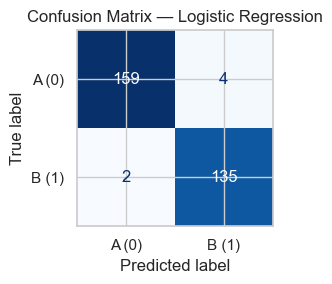

In [9]:
cm_lgr = confusion_matrix(y_test, lgr_pred, labels=['A', 'B'])

print('Confusion Matrix — Logistic Regression')
print(f'  (rows=actual, cols=predicted)')
print(cm_lgr)
print(f'Accuracy: {(lgr_pred == y_test).mean():.4f}')

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm_lgr, display_labels=['A (0)', 'B (1)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

## Prediction Metrics

Mirrors R:
```r
lgr.metrics <- prediction.metrics(ifelse(df.test$Y=='A', 0, 1), lgr.pred)
print.the.metrics(lgr.metrics)
```

In [10]:
lgr_metrics = PredictionMetrics(y_test_n.values, lgr_pred_n)
lgr_metrics.print_metrics()

 OBS =    300   ..................number of observations
 ACC =   0.9800 ..................Accuracy
 TPR =   0.9854 ..................True Positive Rate (Sensitivity)
 TNR =   0.9755 ..................True Negative Rate (Specificity)
 PPV =   0.9712 ..................Positive Predictive Value (Precision)
 NPV =   0.9876 ..................Negative Predictive Value
 FDR =   0.0288 ..................False Discovery Rate
 FPR =   0.0245 ..................False Positive Rate
 TP  =    135   ..................True Positives
 TN  =    159   ..................True Negatives
 FP  =      4   ..................False Positives
 FN  =      2   ..................False Negatives
 P   =    137   ..................Positives (truth)
 N   =    163   ..................Negatives (truth)


## Classification Report

Mirrors R: `caret::confusionMatrix()`

In [11]:
print('Classification Report — Logistic Regression')
print(classification_report(y_test, lgr_pred, target_names=['A', 'B']))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

           A       0.99      0.98      0.98       163
           B       0.97      0.99      0.98       137

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



## ROC Curve

Mirrors R intent (fixing the `p1[,2]` workaround): uses `predict_proba()[:, 1]` directly.

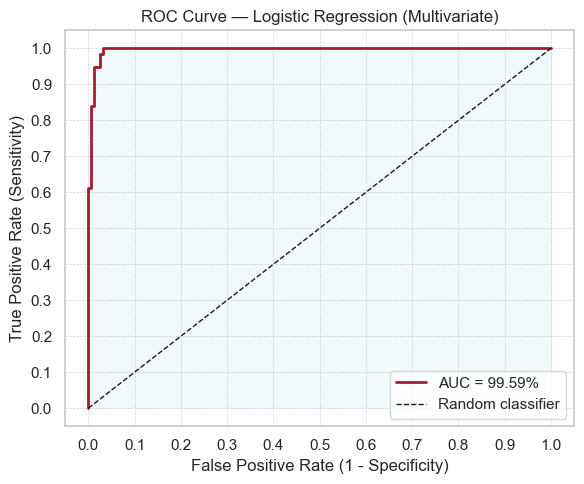

AUC (Logistic Regression): 99.59%


In [12]:
# ROC — using predict_proba directly (fixes R's p1[,2] workaround)
fpr_lgr, tpr_lgr, _ = roc_curve(y_test_n, lgr_probs)
auc_lgr = auc(fpr_lgr, tpr_lgr)

plot_roc(fpr_lgr, tpr_lgr, auc_lgr,
         title='ROC Curve — Logistic Regression (Multivariate)',
         color=CRIMSON)

print(f'AUC (Logistic Regression): {auc_lgr * 100:.2f}%')

---

# 2. Linear Discriminant Analysis (LDA)

Mirrors R: `lda(Y ~ ., data=df.train)` from `library(MASS)`

With four predictors, LDA finds the **linear combination** of V1–V4 that best
separates classes A and B, assuming equal covariance matrices.

## Fit the Model

In [13]:
# Fit LDA — mirrors R: lda(Y~., data=df.train)
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

print('LDA — Model Summary')
print(f'  Classes      : {lda.classes_}')
print(f'  Class priors : {dict(zip(lda.classes_, lda.priors_))}')
print()
print('  Group means (per class):')
for cls, mean in zip(lda.classes_, lda.means_):
    print(f'    {cls}: ' + ', '.join(f'{f}={v:.4f}' for f, v in zip(FEATURES, mean)))
print()
print('  LD1 coefficients:')
for feat, coef in zip(FEATURES, lda.coef_[0]):
    print(f'    {feat}: {coef:.6f}')

LDA — Model Summary
  Classes      : ['A' 'B']
  Class priors : {np.str_('A'): np.float64(0.48142857142857143), np.str_('B'): np.float64(0.5185714285714286)}

  Group means (per class):
    A: V1=-0.0065, V2=-0.9734, V3=-2.9159, V4=1.9404
    B: V1=-1.0164, V2=-2.9663, V3=2.0829, V4=-0.0031

  LD1 coefficients:
    V1: -0.902867
    V2: -0.729330
    V3: 1.979236
    V4: -2.125133


## Predict

In [14]:
# Predict — mirrors R: lda.pred <- predict(lda.fit, df.test)
lda_pred   = lda.predict(X_test)               # class labels 'A'/'B' — mirrors lda.pred$class
lda_probs  = lda.predict_proba(X_test)[:, 1]   # P(Y='B') — mirrors lda.pred$posterior[,2]
lda_pred_n = (lda_probs > 0.5).astype(int)     # numeric 0/1 for PredictionMetrics

print(f'Predicted A : {(lda_pred == "A").sum()}')
print(f'Predicted B : {(lda_pred == "B").sum()}')

Predicted A : 159
Predicted B : 141


## Confusion Matrix

Confusion Matrix — LDA
[[158   5]
 [  1 136]]
Accuracy: 0.9800


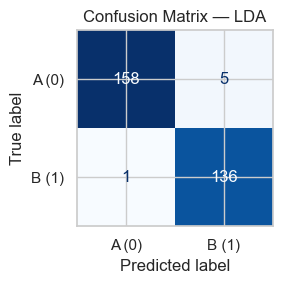

In [15]:
cm_lda = confusion_matrix(y_test, lda_pred, labels=['A', 'B'])

print('Confusion Matrix — LDA')
print(cm_lda)
print(f'Accuracy: {(lda_pred == y_test).mean():.4f}')

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm_lda, display_labels=['A (0)', 'B (1)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — LDA')
plt.tight_layout()
plt.show()

## Prediction Metrics

**Note:** The original R script accidentally passed `lgr.pred` to the LDA metrics
function instead of `lda.pred`. Fixed here — `lda_pred_n` is used correctly.

In [16]:
# Fixed: uses lda_pred_n (not lgr_pred_n) — corrects R script bug
lda_metrics = PredictionMetrics(y_test_n.values, lda_pred_n)
lda_metrics.print_metrics()

 OBS =    300   ..................number of observations
 ACC =   0.9800 ..................Accuracy
 TPR =   0.9927 ..................True Positive Rate (Sensitivity)
 TNR =   0.9693 ..................True Negative Rate (Specificity)
 PPV =   0.9645 ..................Positive Predictive Value (Precision)
 NPV =   0.9937 ..................Negative Predictive Value
 FDR =   0.0355 ..................False Discovery Rate
 FPR =   0.0307 ..................False Positive Rate
 TP  =    136   ..................True Positives
 TN  =    158   ..................True Negatives
 FP  =      5   ..................False Positives
 FN  =      1   ..................False Negatives
 P   =    137   ..................Positives (truth)
 N   =    163   ..................Negatives (truth)


## Classification Report

In [17]:
print('Classification Report — LDA')
print(classification_report(y_test, lda_pred, target_names=['A', 'B']))

Classification Report — LDA
              precision    recall  f1-score   support

           A       0.99      0.97      0.98       163
           B       0.96      0.99      0.98       137

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



## ROC Curve

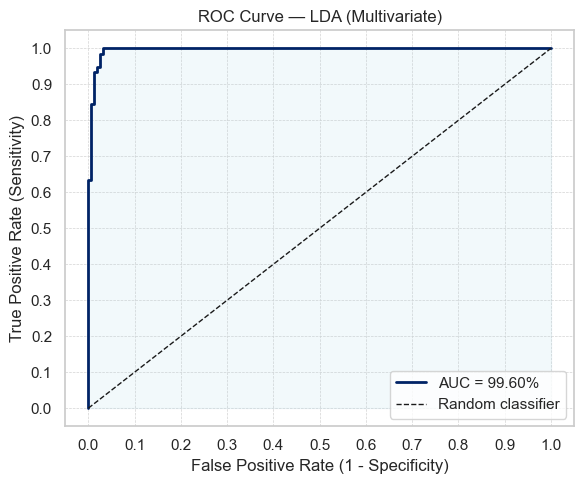

AUC (LDA): 99.60%


In [18]:
fpr_lda, tpr_lda, _ = roc_curve(y_test_n, lda_probs)
auc_lda = auc(fpr_lda, tpr_lda)

plot_roc(fpr_lda, tpr_lda, auc_lda,
         title='ROC Curve — LDA (Multivariate)',
         color=ROYALBLUE)

print(f'AUC (LDA): {auc_lda * 100:.2f}%')

---

# 3. Quadratic Discriminant Analysis (QDA)

Mirrors R: `qda(Y ~ ., data=df.train)` from `library(MASS)`

With four predictors and **different variances per class** in the simulated data
(e.g., V2 and V3 use sd=2 for one class half), QDA has an opportunity to
exploit class-specific covariance structure that LDA cannot.

## Fit the Model

In [19]:
# Fit QDA — mirrors R: qda(Y~., data=df.train)
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

print('QDA — Model Summary')
print(f'  Classes      : {qda.classes_}')
print(f'  Class priors : {dict(zip(qda.classes_, qda.priors_))}')
print()
print('  Group means (per class):')
for cls, mean in zip(qda.classes_, qda.means_):
    print(f'    {cls}: ' + ', '.join(f'{f}={v:.4f}' for f, v in zip(FEATURES, mean)))

QDA — Model Summary
  Classes      : ['A' 'B']
  Class priors : {'A': np.float64(0.48142857142857143), 'B': np.float64(0.5185714285714286)}

  Group means (per class):
    A: V1=-0.0065, V2=-0.9734, V3=-2.9159, V4=1.9404
    B: V1=-1.0164, V2=-2.9663, V3=2.0829, V4=-0.0031


## Predict

In [20]:
# Predict — mirrors R: qda.pred <- predict(qda.fit, df.test)
qda_pred   = qda.predict(X_test)               # class labels — mirrors qda.pred$class
qda_probs  = qda.predict_proba(X_test)[:, 1]   # P(Y='B') — mirrors qda.pred$posterior[,2]
qda_pred_n = (qda_probs > 0.5).astype(int)     # numeric 0/1 for PredictionMetrics

print(f'Predicted A : {(qda_pred == "A").sum()}')
print(f'Predicted B : {(qda_pred == "B").sum()}')

Predicted A : 162
Predicted B : 138


## Confusion Matrix

Confusion Matrix — QDA
[[159   4]
 [  3 134]]
Accuracy: 0.9767


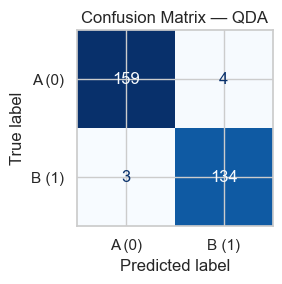

In [21]:
cm_qda = confusion_matrix(y_test, qda_pred, labels=['A', 'B'])

print('Confusion Matrix — QDA')
print(cm_qda)
print(f'Accuracy: {(qda_pred == y_test).mean():.4f}')

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm_qda, display_labels=['A (0)', 'B (1)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — QDA')
plt.tight_layout()
plt.show()

## Prediction Metrics

**Note:** The original R script accidentally passed `lgr.pred` to the QDA metrics
function instead of `qda.pred`. Fixed here — `qda_pred_n` is used correctly.

In [22]:
# Fixed: uses qda_pred_n (not lgr_pred_n) — corrects R script bug
qda_metrics = PredictionMetrics(y_test_n.values, qda_pred_n)
qda_metrics.print_metrics()

 OBS =    300   ..................number of observations
 ACC =   0.9767 ..................Accuracy
 TPR =   0.9781 ..................True Positive Rate (Sensitivity)
 TNR =   0.9755 ..................True Negative Rate (Specificity)
 PPV =   0.9710 ..................Positive Predictive Value (Precision)
 NPV =   0.9815 ..................Negative Predictive Value
 FDR =   0.0290 ..................False Discovery Rate
 FPR =   0.0245 ..................False Positive Rate
 TP  =    134   ..................True Positives
 TN  =    159   ..................True Negatives
 FP  =      4   ..................False Positives
 FN  =      3   ..................False Negatives
 P   =    137   ..................Positives (truth)
 N   =    163   ..................Negatives (truth)


## Classification Report

In [23]:
print('Classification Report — QDA')
print(classification_report(y_test, qda_pred, target_names=['A', 'B']))

Classification Report — QDA
              precision    recall  f1-score   support

           A       0.98      0.98      0.98       163
           B       0.97      0.98      0.97       137

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



## ROC Curve

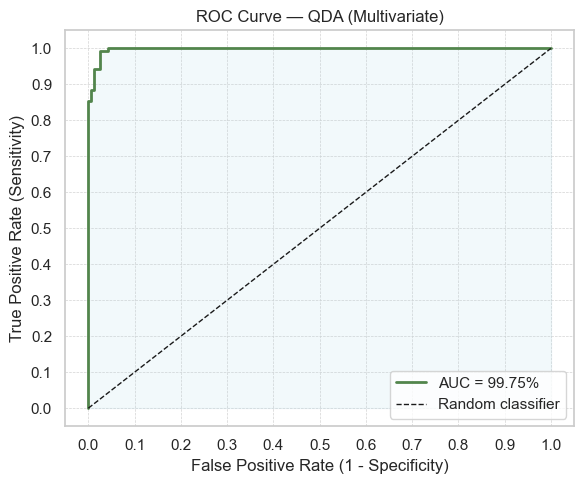

AUC (QDA): 99.75%


In [24]:
fpr_qda, tpr_qda, _ = roc_curve(y_test_n, qda_probs)
auc_qda = auc(fpr_qda, tpr_qda)

plot_roc(fpr_qda, tpr_qda, auc_qda,
         title='ROC Curve — QDA (Multivariate)',
         color=IVY)

print(f'AUC (QDA): {auc_qda * 100:.2f}%')

---

# Summary and Conclusions

## Model Comparison

In [25]:
# Summary comparison table
comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', **lgr_metrics.to_dict(), 'AUC': auc_lgr},
    {'Model': 'LDA',                 **lda_metrics.to_dict(), 'AUC': auc_lda},
    {'Model': 'QDA',                 **qda_metrics.to_dict(), 'AUC': auc_qda},
])

key_cols = ['Model', 'OBS', 'ACC', 'TPR', 'TNR', 'PPV', 'FPR', 'AUC']
print('Model Comparison — Key Metrics (Multivariate)')
print(comparison[key_cols].to_string(index=False, float_format='{:.4f}'.format))

Model Comparison — Key Metrics (Multivariate)
              Model  OBS    ACC    TPR    TNR    PPV    FPR    AUC
Logistic Regression  300 0.9800 0.9854 0.9755 0.9712 0.0245 0.9959
                LDA  300 0.9800 0.9927 0.9693 0.9645 0.0307 0.9960
                QDA  300 0.9767 0.9781 0.9755 0.9710 0.0245 0.9975


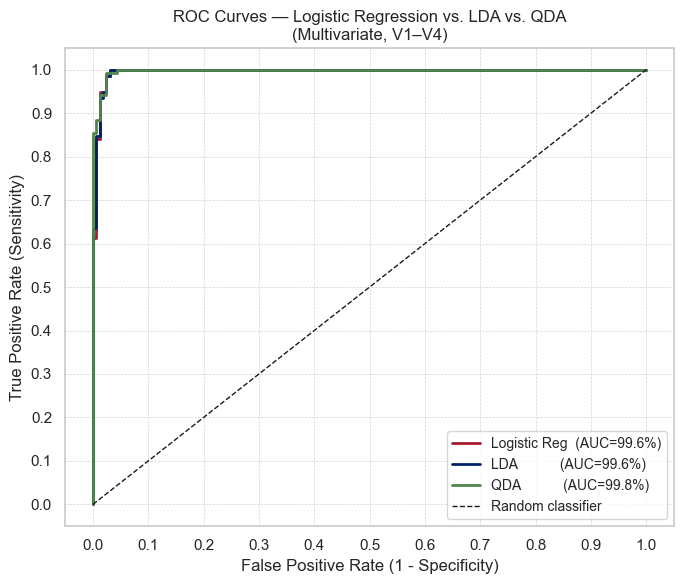

In [26]:
# Overlay all three ROC curves
fig, ax = plt.subplots(figsize=(7, 6))

for (fpr, tpr, roc_auc, label, color) in [
    (fpr_lgr, tpr_lgr, auc_lgr, f'Logistic Reg  (AUC={auc_lgr*100:.1f}%)', CRIMSON),
    (fpr_lda, tpr_lda, auc_lda, f'LDA           (AUC={auc_lda*100:.1f}%)', ROYALBLUE),
    (fpr_qda, tpr_qda, auc_qda, f'QDA           (AUC={auc_qda*100:.1f}%)', IVY),
]:
    ax.plot(fpr, tpr, linewidth=2, label=label, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.grid(True, linestyle='--', linewidth=0.5, color='lightgrey')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — Logistic Regression vs. LDA vs. QDA\n(Multivariate, V1–V4)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Multivariate vs. univariate:** With four predictors instead of one, all three
   classifiers generally improve — each predictor contributes signal that the
   univariate model cannot capture.

2. **QDA advantage:** Because the simulated data uses different standard deviations
   per predictor half (sd=1 vs sd=2 in V2 and V3), QDA's per-class covariance
   estimation gives it an edge over LDA's shared-covariance assumption.

3. **Bugs corrected from R:** Both the LDA and QDA metrics in the original R script
   accidentally used `lgr.pred` — this Python version uses the correct predictions
   for each model, giving meaningful independent metrics per classifier.

4. **ROC fix:** The R logistic ROC used a `predict(..., type='terms')[,2]` workaround
   noted as potentially buggy. Python's `predict_proba()[:, 1]` is clean and direct.

5. **Portfolio tip:** The `PredictionMetrics` class and `plot_roc()` helper are
   now used across notebooks #2 and #3. A natural next step is to extract them
   into a shared `utils.py` in the `machine_learning/` folder.

## R → Python Mapping

| R | Python |
|---|--------|
| `glm(Y~., family=binomial)` | `LogisticRegression(penalty=None)` + all features |
| `lda(Y~., data=train)` | `LinearDiscriminantAnalysis()` |
| `qda(Y~., data=train)` | `QuadraticDiscriminantAnalysis()` |
| `Y ~ .` (all predictors) | `X_train = df_train[['V1','V2','V3','V4']]` |
| `factor(y)` | string labels `'A'`/`'B'` (sklearn handles natively) |
| `ifelse(df.test$Y=='A', 0, 1)` | `np.where(y_label == 'A', 0, 1)` |
| `GGally::ggpairs()` | `seaborn.pairplot()` |
| `predict(glm, type='terms')[,2]` | `predict_proba(X_test)[:, 1]` (cleaner) |
| `lda.pred$posterior[,2]` | `lda.predict_proba(X_test)[:, 1]` |
| `qda.pred$posterior[,1]` | `qda.predict_proba(X_test)[:, 1]` |

## References

1. Harvard "Elements of Statistical Learning" (2021), Dr. Sivachenko and Dr. Farutin.
2. Gareth James, et al. *An Introduction to Statistical Learning with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
3. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J. *An Introduction to Statistical Learning with Applications in Python*. Springer, 2023. https://www.statlearning.com